In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

In [2]:
# ====================== 1. LOAD DATASET GỐC ======================
print("Đang load dataset gốc...")
base_df = pd.read_csv("data/Churn_Modelling.csv")   # ← thay tên file nếu khác
print(f"Dataset gốc: {base_df.shape[0]} dòng, {base_df.shape[1]} cột")

# ====================== 2. XÓA CÁC CỘT KHÔNG CẦN THIẾT ======================
# Xóa RowNumber, CustomerId, Surname (không dùng cho model + bảo mật)
base_df = base_df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"Sau khi xóa cột thừa: {base_df.shape[1]} cột còn lại")

Đang load dataset gốc...
Dataset gốc: 10000 dòng, 14 cột
Sau khi xóa cột thừa: 11 cột còn lại


In [3]:
# ====================== 3. TẠO DỮ LIỆU TỔNG HỢP 50.000 DÒNG ======================
np.random.seed(42)  # để kết quả lặp lại được

print("Đang tạo 50.000 dòng synthetic dựa trên phân phối gốc...")

# Bootstrap + noise (giữ nguyên mối quan hệ giữa các biến)
df = base_df.sample(n=50000, replace=True).reset_index(drop=True)

# Thêm nhiễu Gaussian nhỏ cho các cột số (làm dữ liệu "thật" hơn)
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_cols:
    std = df[col].std()
    noise = np.random.normal(0, std * 0.05, size=50000)   # 5% nhiễu
    df[col] = df[col] + noise
    
    # Giới hạn hợp lý
    if col == 'Age':
        df[col] = df[col].clip(18, 92)
    elif col == 'CreditScore':
        df[col] = df[col].clip(350, 850)
    elif col == 'Tenure':
        df[col] = df[col].clip(0, 10)
    elif col == 'Balance':
        df[col] = df[col].clip(0, None)
    elif col == 'NumOfProducts':
        df[col] = df[col].round().clip(1, 4).astype(int)
print("Synthetic dataset đã được tạo với 50.000 dòng.")


Đang tạo 50.000 dòng synthetic dựa trên phân phối gốc...
Synthetic dataset đã được tạo với 50.000 dòng.


In [4]:
# ====================== 4. PHÁT TRIỂN THÊM 4 FEATURE MỚI (Mobile Banking) ======================
# Những feature này rất phù hợp với dự án ngân hàng số + dễ tạo derived features sau
print("Đang thêm feature mới phù hợp churn ngân hàng số...")

df['login_count_last_30d'] = np.random.poisson(lam=12, size=50000) * \
                                 (df['IsActiveMember'] + 0.3)
df['login_count_last_30d'] = df['login_count_last_30d'].clip(0, 60).astype(int)

df['num_transactions_last_90d'] = np.random.poisson(lam=18, size=50000) * \
                                       (df['IsActiveMember'] + 0.5)
df['num_transactions_last_90d'] = df['num_transactions_last_90d'].clip(0, 120).astype(int)

df['avg_transaction_amount'] = np.random.lognormal(mean=8.5, sigma=1.2, size=50000) * \
                                    (1 + df['Balance']/100000)
df['avg_transaction_amount'] = df['avg_transaction_amount'].clip(100, 50000).round(2)

df['complaint_count_last_12m'] = np.random.poisson(lam=0.8, size=50000) * \
                                      (1 - df['IsActiveMember'] * 0.4)
df['complaint_count_last_12m'] = df['complaint_count_last_12m'].clip(0, 8).astype(int)

# ====================== 5. LƯU FILE ======================
df.to_csv('synthetic_bank_churn_50000.csv', index=False)

print("\n✅ HOÀN TẤT!")
print(f"File đã tạo: synthetic_bank_churn_50000.csv")
print(f"→ Số dòng: {len(df)}")
print(f"→ Số cột: {df.shape[1]} (đã xóa thừa + thêm mới)")
print(f"→ Biến mục tiêu: Exited (churn)")
print("\nCác cột hiện có:")
print(df.columns.tolist())

Đang thêm feature mới phù hợp churn ngân hàng số...

✅ HOÀN TẤT!
File đã tạo: synthetic_bank_churn_50000.csv
→ Số dòng: 50000
→ Số cột: 15 (đã xóa thừa + thêm mới)
→ Biến mục tiêu: Exited (churn)

Các cột hiện có:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'login_count_last_30d', 'num_transactions_last_90d', 'avg_transaction_amount', 'complaint_count_last_12m']



So sánh phân phối biến Exited (churn):
Dataset gốc (%):
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64

Dataset synthetic (%):
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


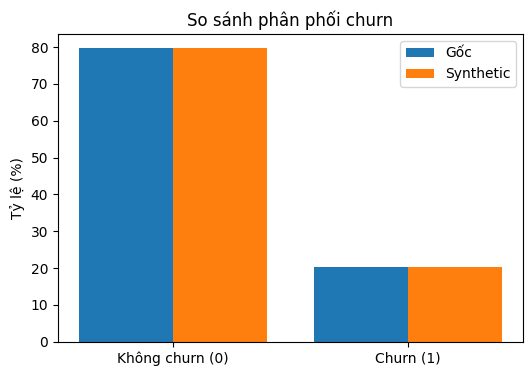

In [5]:
# ====================== 6. KIỂM TRA PHÂN PHỐI CHURN ======================
print("\nSo sánh phân phối biến Exited (churn):")

# Phân phối trong dataset gốc
orig_dist = base_df['Exited'].value_counts(normalize=True).round(3) * 100
print("Dataset gốc (%):")
print(orig_dist)

# Phân phối trong dataset synthetic
synthetic_dist = df['Exited'].value_counts(normalize=True).round(3) * 100
print("\nDataset synthetic (%):")
print(synthetic_dist)

# So sánh trực quan
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(orig_dist.index - 0.2, orig_dist.values, width=0.4, label='Gốc')
plt.bar(synthetic_dist.index + 0.2, synthetic_dist.values, width=0.4, label='Synthetic')
plt.xticks([0,1], ['Không churn (0)', 'Churn (1)'])
plt.ylabel('Tỷ lệ (%)')
plt.title('So sánh phân phối churn')
plt.legend()
plt.show()